In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("youtube_analytics.csv")

In [3]:
df

,video_id,day,views,redViews,comments,likes,dislikes,videosAddedToPlaylists,videosRemovedFromPlaylists,shares,...,annotationClicks,annotationCloses,cardClickRate,cardTeaserClickRate,cardImpressions,cardTeaserImpressions,cardClicks,cardTeaserClicks,subscribersGained,subscribersLost
0,YuQaT52VEwo,2019-09-06,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,YuQaT52VEwo,2019-09-07,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SfTEVOQP-Hk,2019-09-07,6.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,YuQaT52VEwo,2019-09-08,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SfTEVOQP-Hk,2019-09-08,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234884,jCBMPRa88_4,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234885,bN7jBc95XDo,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234886,ZwtHeB7L6lA,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234887,5DM_c9zMn0U,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.columns

Index(['video_id', 'day', 'views', 'redViews', 'comments', 'likes', 'dislikes',
       'videosAddedToPlaylists', 'videosRemovedFromPlaylists', 'shares',
       'estimatedMinutesWatched', 'estimatedRedMinutesWatched',
       'averageViewDuration', 'averageViewPercentage',
       'annotationClickThroughRate', 'annotationCloseRate',
       'annotationImpressions', 'annotationClickableImpressions',
       'annotationClosableImpressions', 'annotationClicks', 'annotationCloses',
       'cardClickRate', 'cardTeaserClickRate', 'cardImpressions',
       'cardTeaserImpressions', 'cardClicks', 'cardTeaserClicks',
       'subscribersGained', 'subscribersLost'],
      dtype='object')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

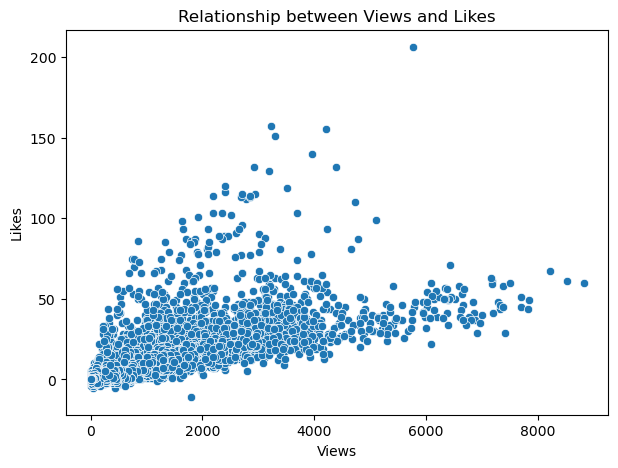

In [6]:
# Relationship between views and likes
plt.figure(figsize=(7, 5))
sns.scatterplot(x='views', y='likes', data=df)
plt.title('Relationship between Views and Likes')
plt.xlabel('Views')
plt.ylabel('Likes')
plt.show()

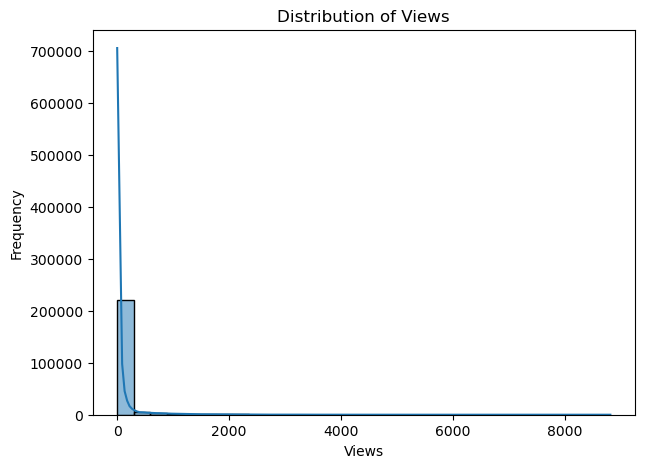

In [7]:
# Explore individual columns
# Example: Distribution of views
plt.figure(figsize=(7, 5))
sns.histplot(df['views'], bins=30, kde=True)
plt.title('Distribution of Views')
plt.xlabel('Views')
plt.ylabel('Frequency')
plt.show()

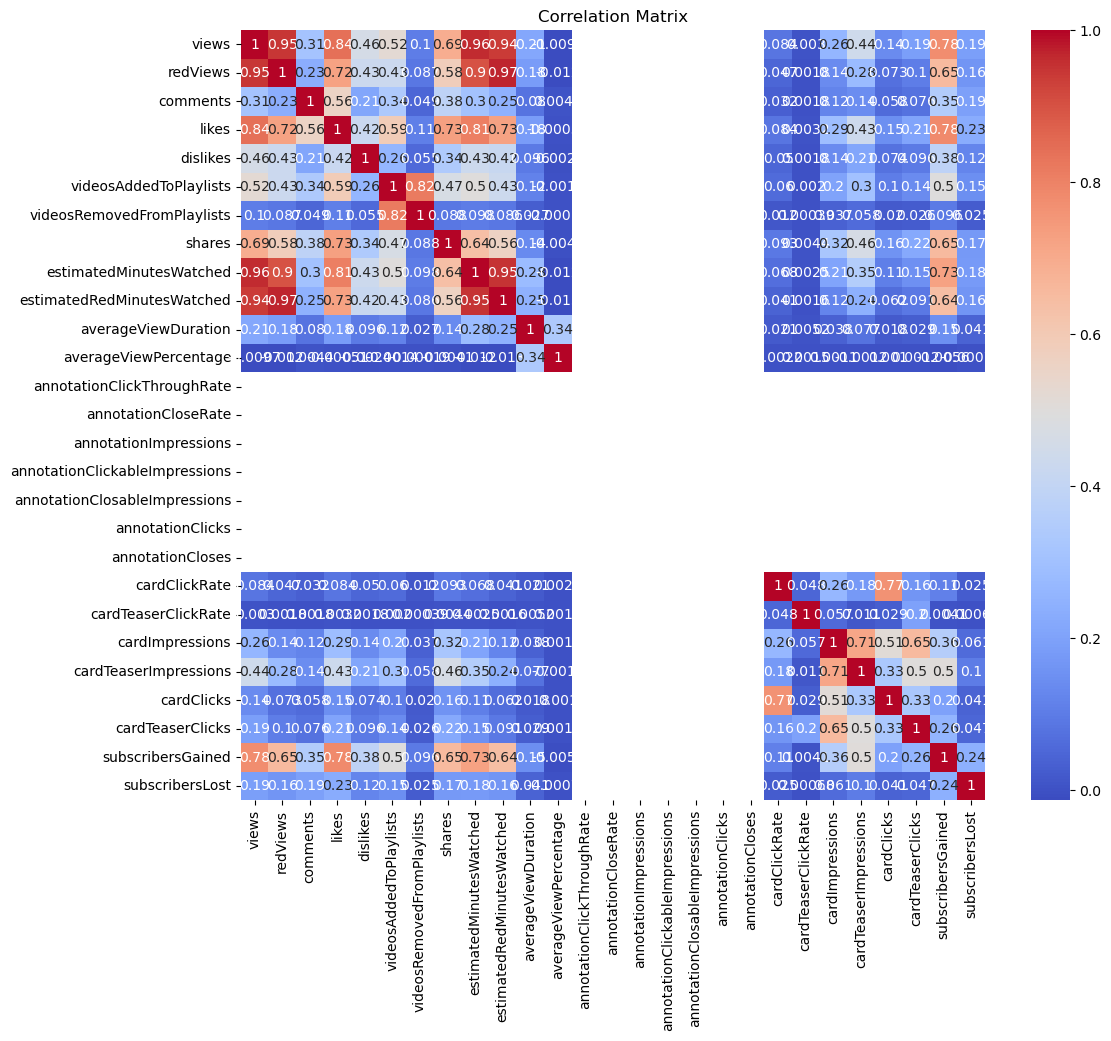

In [8]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')  # Add numeric_only=True
plt.title('Correlation Matrix')
plt.show()

In [18]:
import pandas as pd
import numpy as np

# ... (load and preprocess data as before)

# Select numerical features for PCA
numerical_features = df.select_dtypes(include=['number']).columns
X = df[numerical_features].values

# Remove columns with zero variance
X_std = np.std(X, axis=0)
non_zero_variance_columns = np.where(X_std != 0)[0] 
X = X[:, non_zero_variance_columns] 

# 1. Standardize the data (using only non-zero variance columns)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

# ... (rest of the PCA implementation)
# 2. Calculate the covariance matrix
covariance_matrix = np.cov(X_scaled.T)

# 3. Perform eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# 4. Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# 5. Select principal components (e.g., top 2)
num_components = 5  # Choose the desired number of components
principal_components = eigenvectors[:, :num_components]

# 6. Transform the data to the principal component space
X_pca = X_scaled.dot(principal_components)

# Create a DataFrame with principal components
principal_df = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(num_components)])

# Print the reduced dimensionality table
print(principal_df)

             PC1       PC2       PC3       PC4       PC5
0      -0.617840  0.050397  0.025039  0.082445 -0.046690
1      -0.752190  0.134461 -0.354218 -0.465055  0.078275
2      -0.565456 -0.041291  0.361781  1.085267 -0.210592
3      -0.565947 -0.126493  0.956263  1.902642 -0.395542
4      -0.621453 -0.110407  0.954790  1.935839 -0.412191
...          ...       ...       ...       ...       ...
234884 -1.094129  0.302345 -0.764025 -1.289310  0.188902
234885 -1.094129  0.302345 -0.764025 -1.289310  0.188902
234886 -1.094129  0.302345 -0.764025 -1.289310  0.188902
234887 -1.094129  0.302345 -0.764025 -1.289310  0.188902
234888 -1.094129  0.302345 -0.764025 -1.289310  0.188902

[234889 rows x 5 columns]


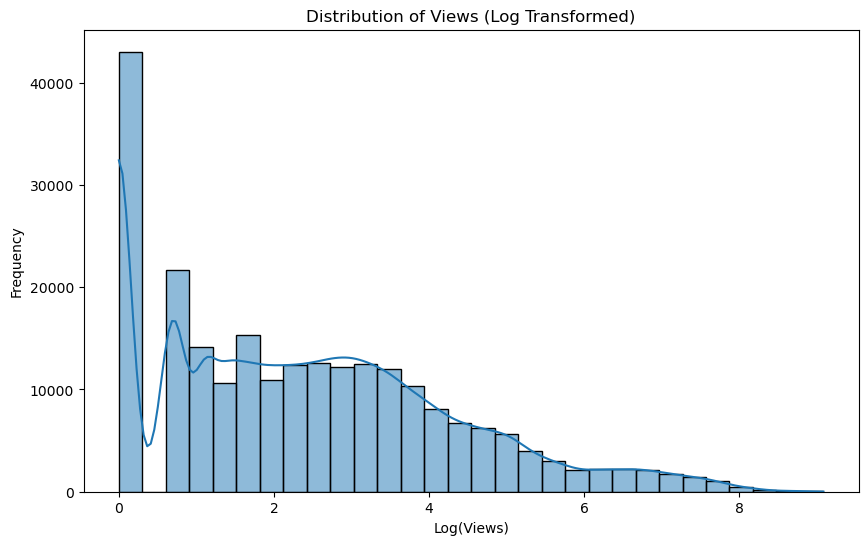

In [19]:
import numpy as np

df['log_views'] = np.log1p(df['views'])  # Using log1p to handle zero values


# Distribution of views (with log transformation)
plt.figure(figsize=(10, 6))
sns.histplot(df['log_views'], bins=30, kde=True)  # Plotting log_views
plt.title('Distribution of Views (Log Transformed)')
plt.xlabel('Log(Views)')
plt.ylabel('Frequency')
plt.show()

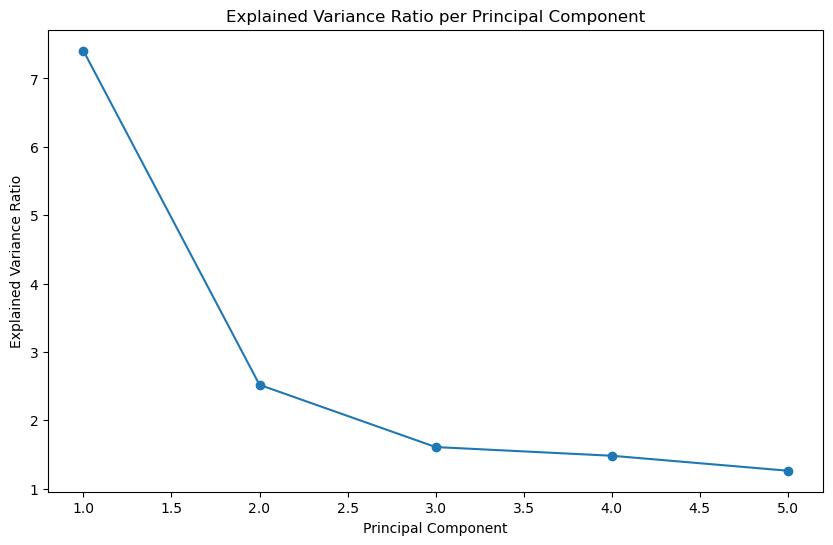

In [20]:
# 1. Explained Variance Ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_components + 1), eigenvalues[:num_components], marker='o')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

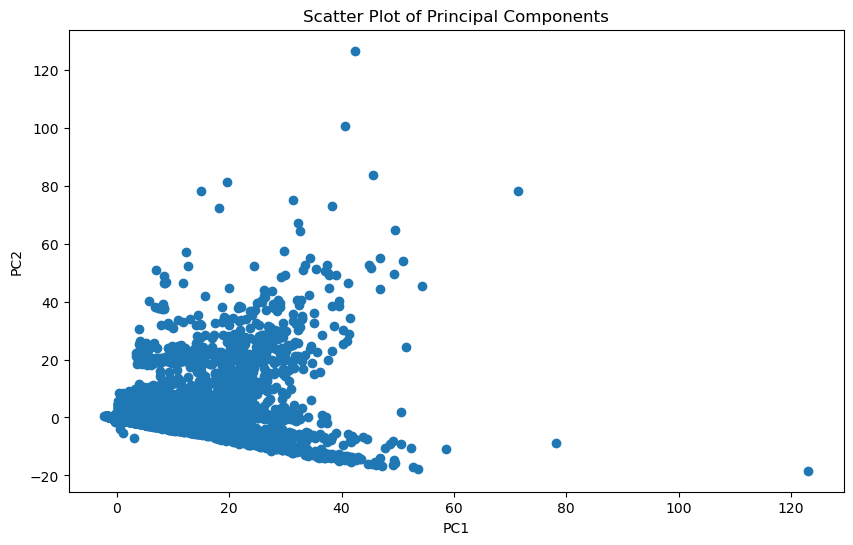

In [21]:
# 2. Scatter Plot of Principal Components
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1])  # Assuming you selected 2 components
plt.title('Scatter Plot of Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

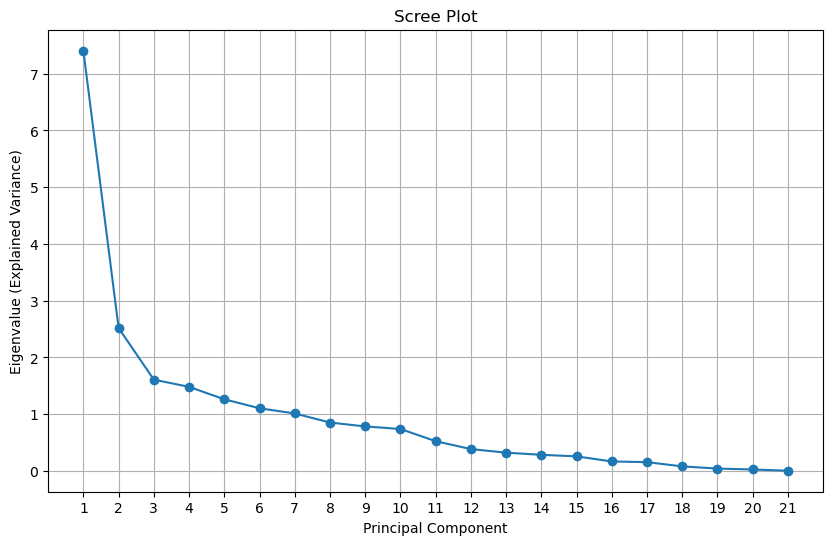

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.xticks(range(1, len(eigenvalues) + 1))  # Set x-axis ticks to component numbers
plt.grid(True)

plt.show()

NameError: name 'pca' is not defined

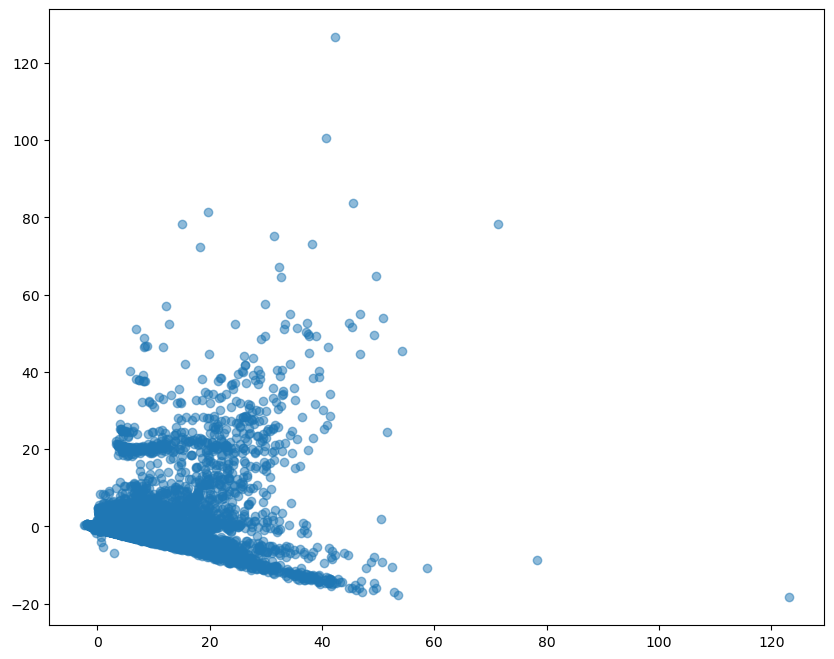

In [23]:
plt.figure(figsize=(10, 8))

# Plot the data points (observations)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)  # Assuming 2 components

# Plot the feature vectors (loadings)
feature_vectors = pca.components_.T  # Get the feature vectors (loadings)
for i, feature in enumerate(numerical_features):
    plt.arrow(0, 0, feature_vectors[i, 0], feature_vectors[i, 1], color='r', alpha=0.7, head_width=0.05)
    plt.text(feature_vectors[i, 0] * 1.15, feature_vectors[i, 1] * 1.15, feature, color='k', ha='center', va='center')

# Customize the plot
plt.title('Biplot of Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim([-1, 1])  # Adjust limits as needed
plt.ylim([-1, 1])
plt.grid(True)

plt.show()

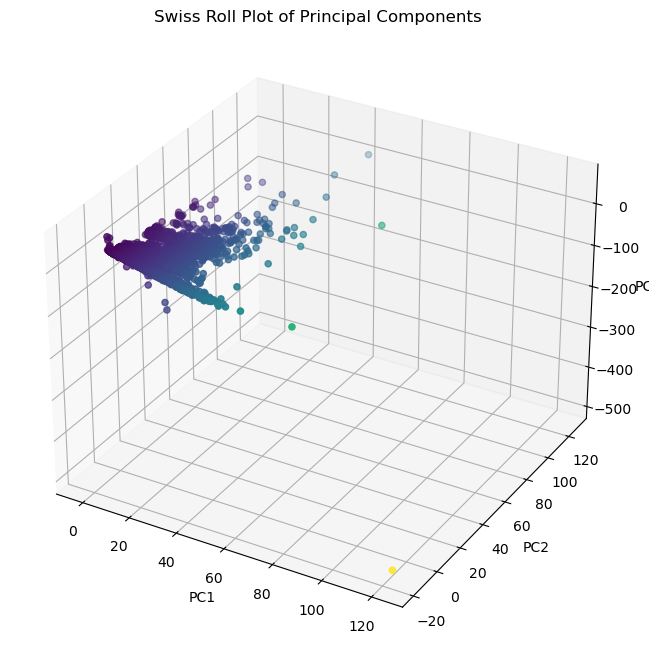

In [24]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=X_pca[:, 0], cmap='viridis')  # Assuming 3 components

# Customize the plot
ax.set_title('Swiss Roll Plot of Principal Components')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()